In [1]:
import os
import glob
import esmpy
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import pandas as pd
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geocat.viz as gv

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

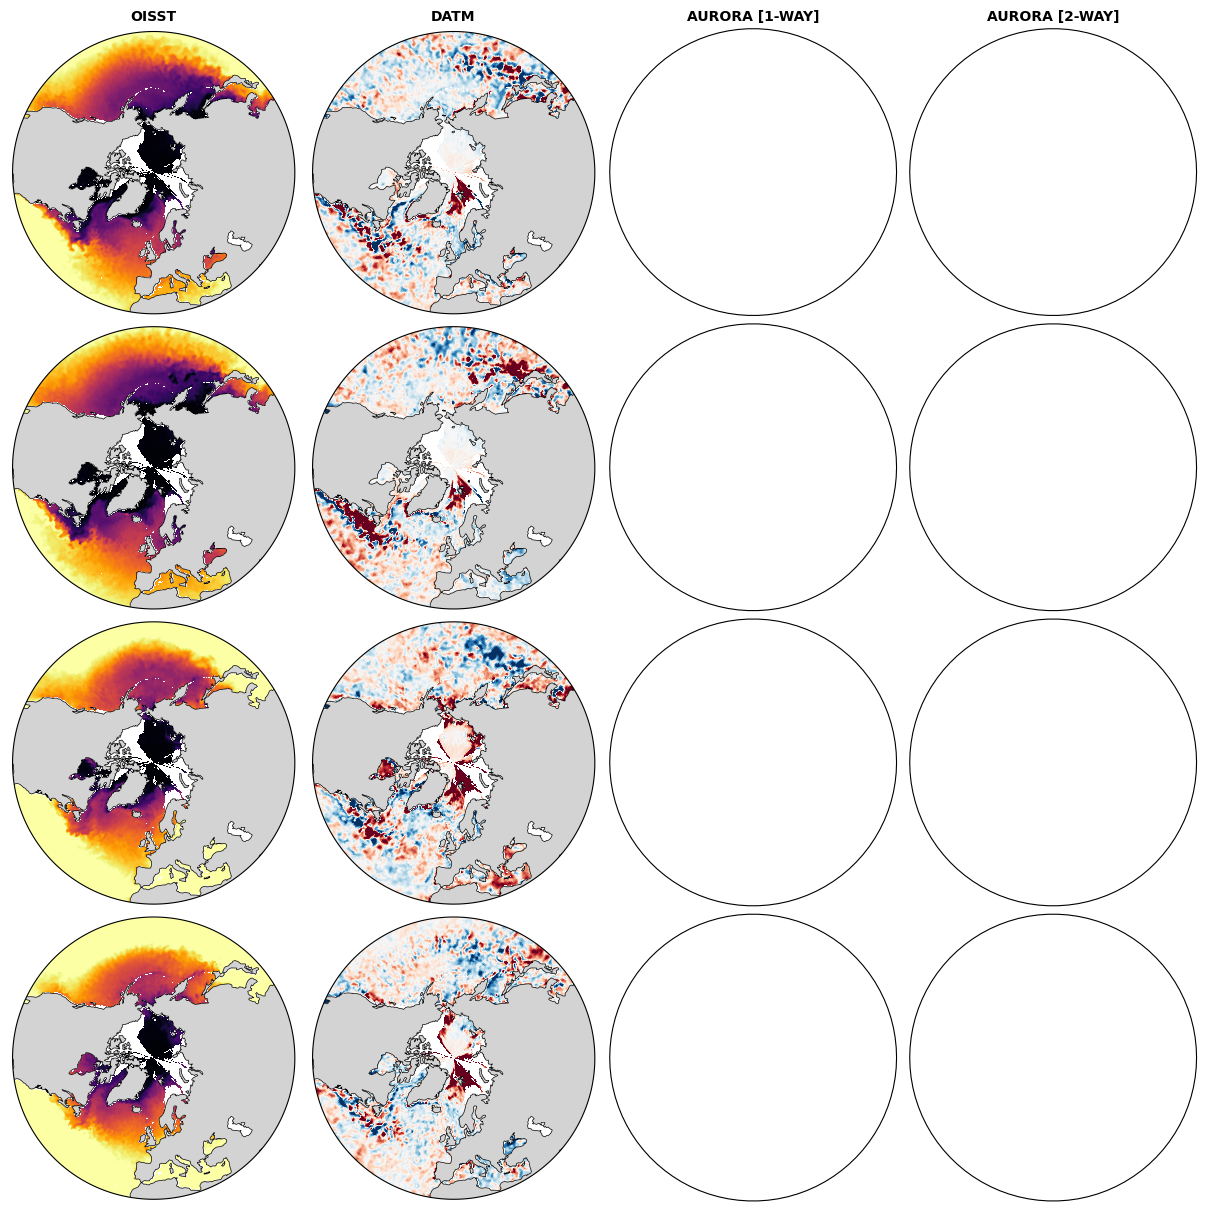

In [33]:
# Create figure
proj = ccrs.NorthPolarStereo()
fig, ax = plt.subplots(4, 4, figsize=(12, 12), layout='constrained', subplot_kw={'projection': proj})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_oisst = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_oisst/oisst_35d_remap_bil.nc")).isel(zlev=0)
    #ds_oisst = ds_oisst.reindex(latitude=ds_oisst.latitude[::-1])
    #ds_datm  = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil.nc")).rename({'SST': 'sst'})
    #ds_datm = ds_datm.reindex(latitude=ds_datm.latitude[::-1])

    # Create mask
    mask = ds_datm.sst.isel(time=0).notnull()

    # OISST
    data_oisst = ds_oisst.sst.where(mask).isel(time=0)
    gv.set_map_boundary(ax[irow,0], [-180, 180], [30, 50], south_pad=1)
    ax[irow,0].add_feature(cfeature.LAND, facecolor='lightgray')
    ax[irow,0].coastlines(linewidth=0.5)
    im0 = data_oisst.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=20, cmap='inferno', add_colorbar=False)

    # DATM
    #data_datm = ds_datm.sst.where(mask).isel(time=0)
    #data_datm_diff = data_datm-data_oisst
    #gv.set_map_boundary(ax[irow,1], [-180, 180], [30, 50], south_pad=1)
    #ax[irow,1].add_feature(cfeature.LAND, facecolor='lightgray')
    #im1 = data_datm_diff.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-2, vmax=2, cmap='RdBu_r', add_colorbar=False)
    #ax[irow,1].coastlines(linewidth=0.5)

    # Labels
    if irow == 0:
        ax[irow,0].set_title("OISST", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("DATM", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("AURORA [1-WAY]", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("AURORA [2-WAY]", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")

    irow = irow+1

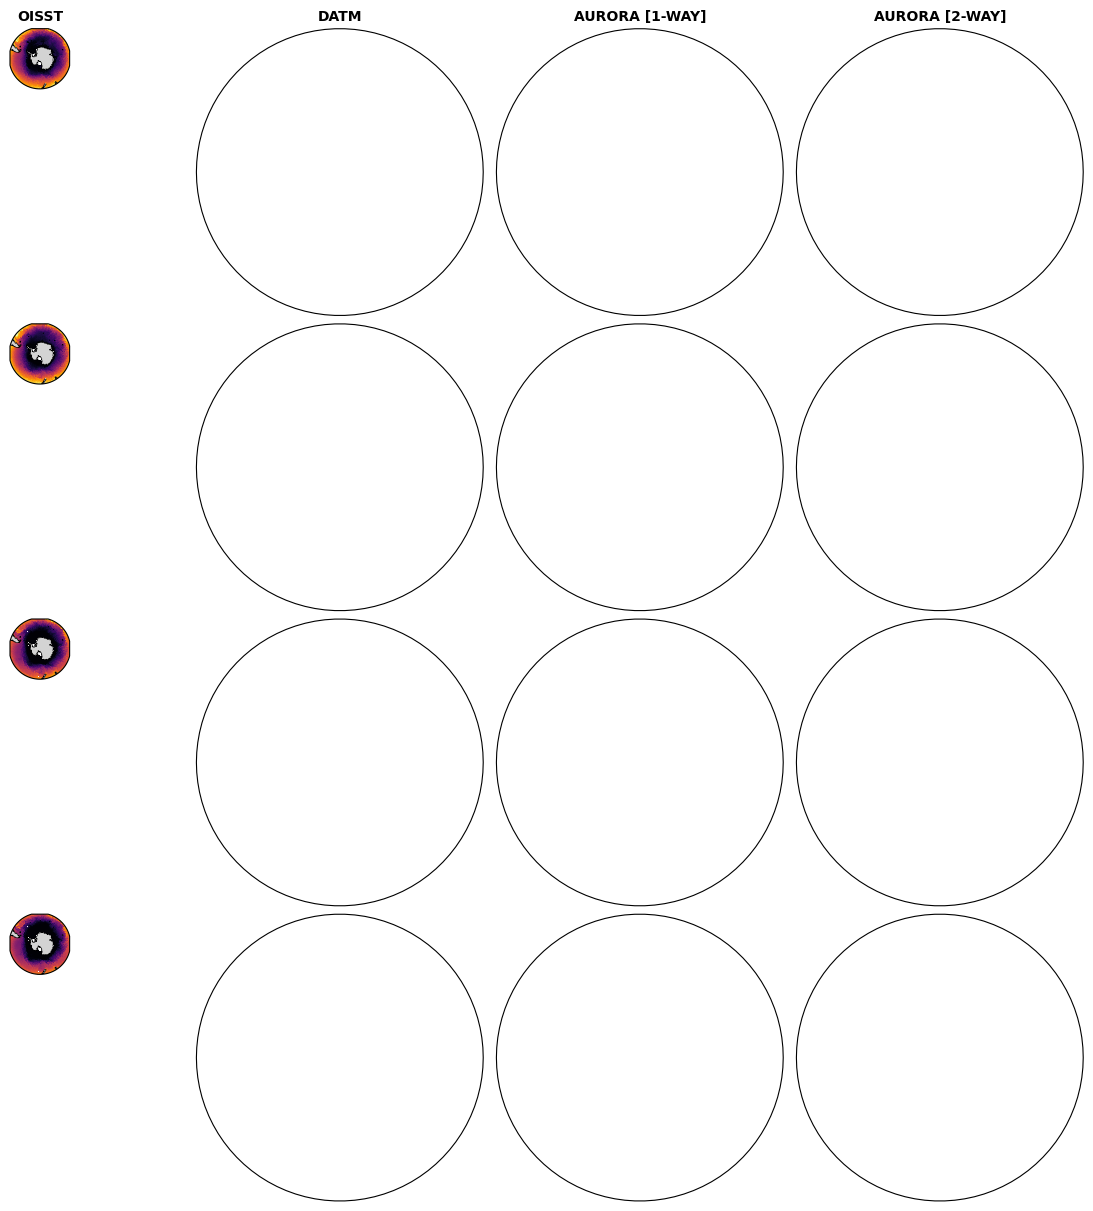

In [35]:
# Create figure
proj = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(4, 4, figsize=(12, 12), layout='constrained', subplot_kw={'projection': proj})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_oisst = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_oisst/oisst_35d_remap_bil.nc")).isel(zlev=0)
    #ds_oisst = ds_oisst.reindex(latitude=ds_oisst.latitude[::-1])
    #ds_datm  = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ocn_merged_35d_remap_bil.nc")).rename({'SST': 'sst'})
    #ds_datm = ds_datm.reindex(latitude=ds_datm.latitude[::-1])

    # Create mask
    mask = ds_datm.sst.isel(time=0).notnull()

    # OISST
    data_oisst = ds_oisst.sst.where(mask).isel(time=0)
    gv.set_map_boundary(ax[irow,0], [-180, 180], [-40, 90], south_pad=1)
    ax[irow,0].add_feature(cfeature.LAND, facecolor='lightgray')
    ax[irow,0].coastlines(linewidth=0.5)
    im0 = data_oisst.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=-2, vmax=20, cmap='inferno', add_colorbar=False)

    # DATM
    #data_datm = ds_datm.sst.where(mask).isel(time=0)
    #data_datm_diff = data_datm-data_oisst
    #gv.set_map_boundary(ax[irow,1], [-180, 180], [30, 50], south_pad=1)
    #ax[irow,1].add_feature(cfeature.LAND, facecolor='lightgray')
    #im1 = data_datm_diff.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-2, vmax=2, cmap='RdBu_r', add_colorbar=False)
    #ax[irow,1].coastlines(linewidth=0.5)

    # Labels
    if irow == 0:
        ax[irow,0].set_title("OISST", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("DATM", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("AURORA [1-WAY]", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("AURORA [2-WAY]", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")

    irow = irow+1